In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif, chi2
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [2]:
#Load dataset
with open("data/features/dataset.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y_labels = data["y"]
feature_names = data["feature_names"]

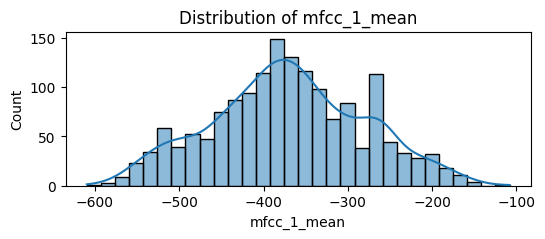

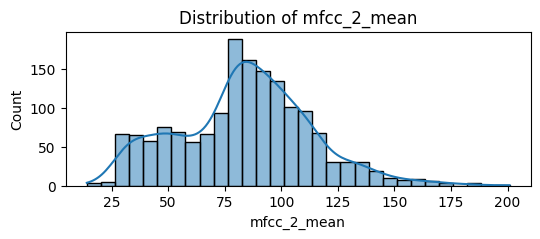

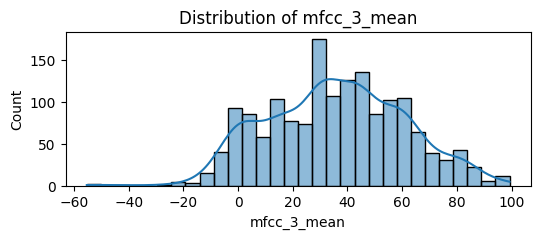

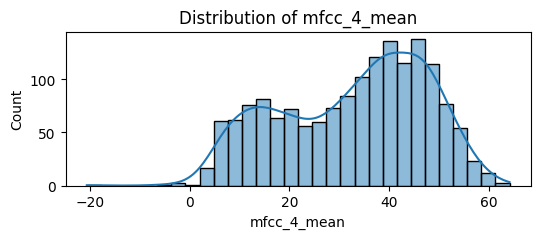

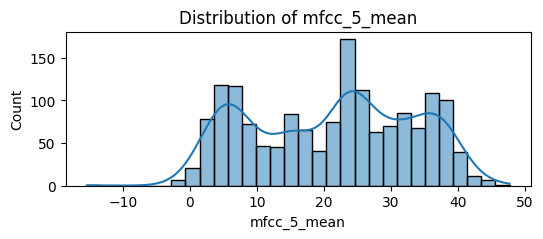

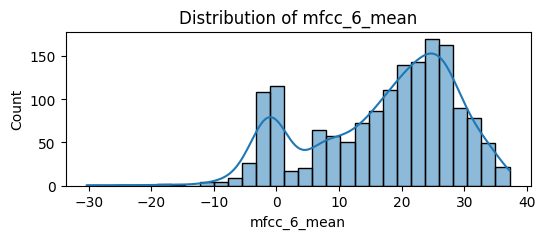

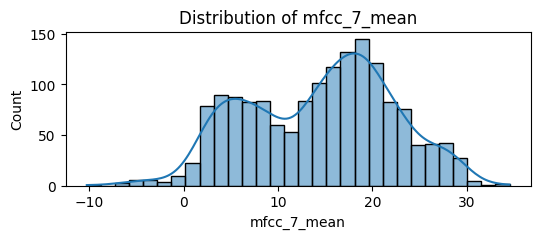

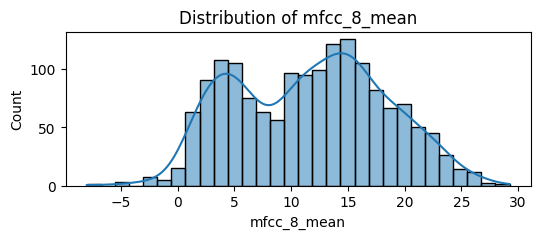

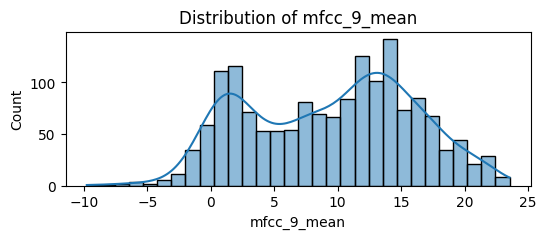

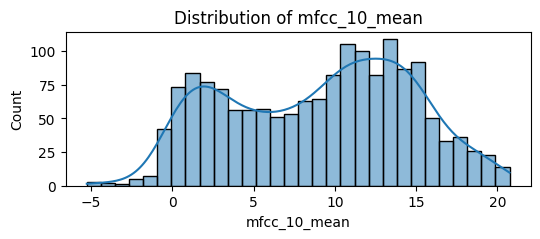

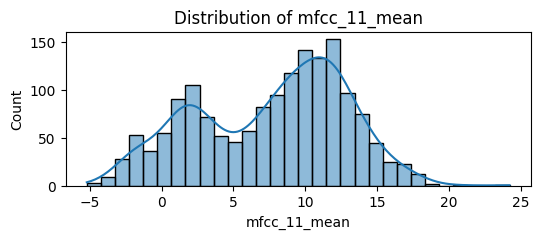

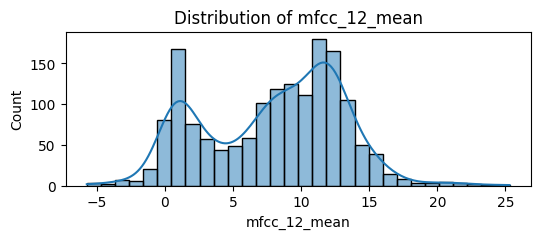

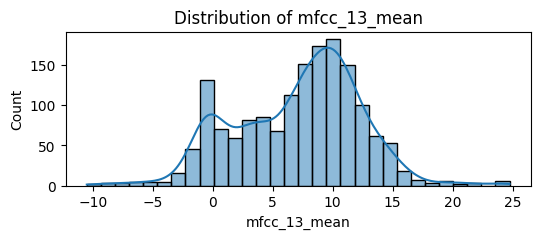

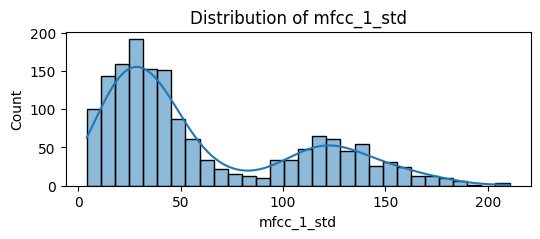

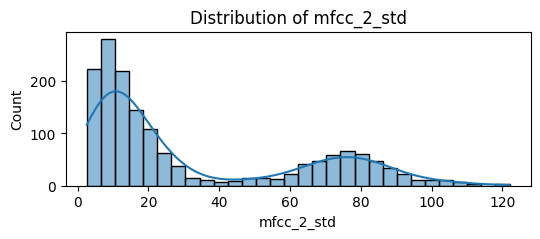

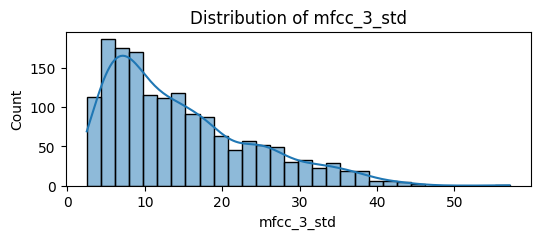

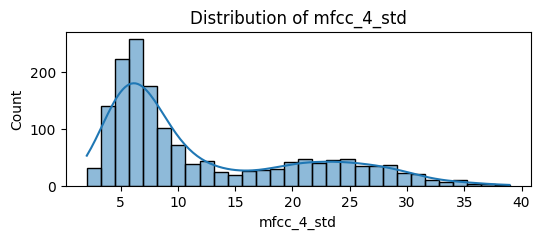

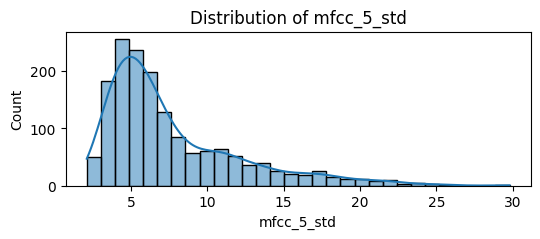

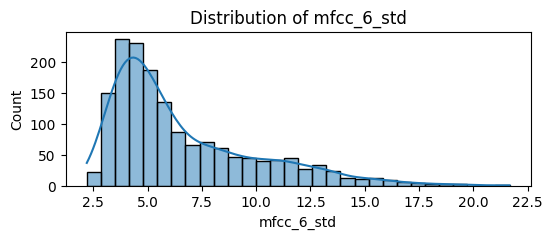

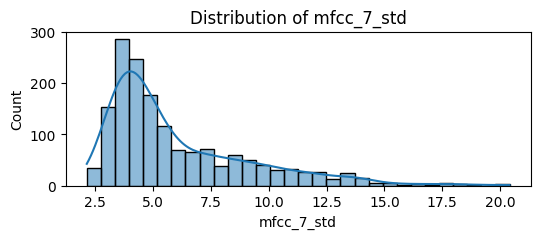

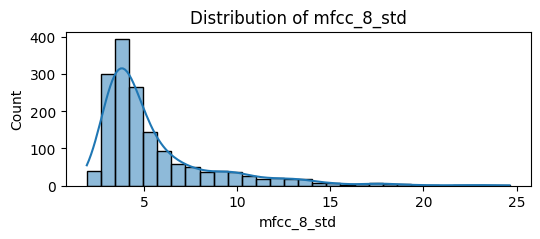

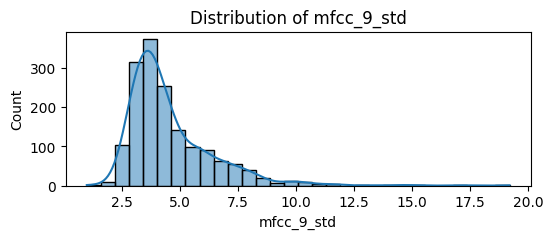

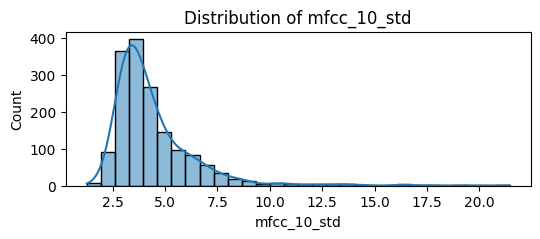

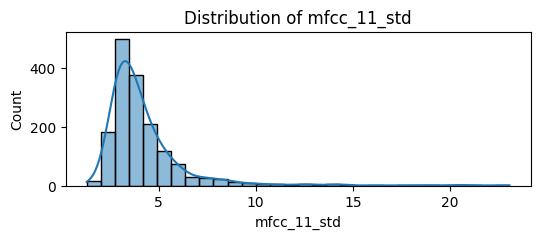

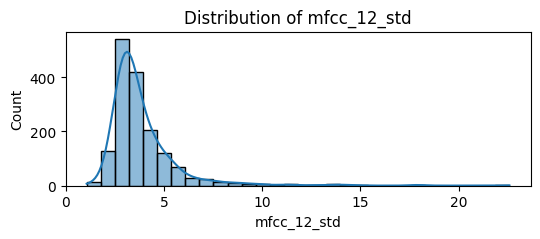

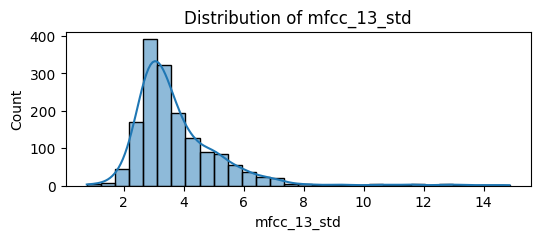

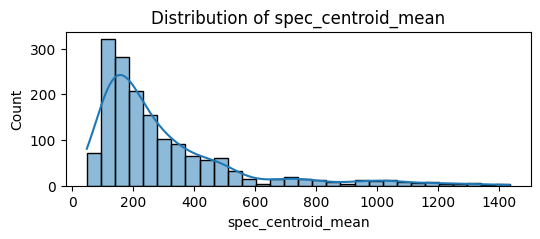

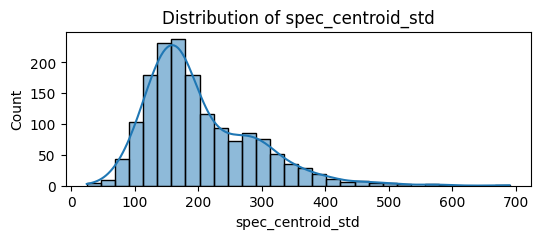

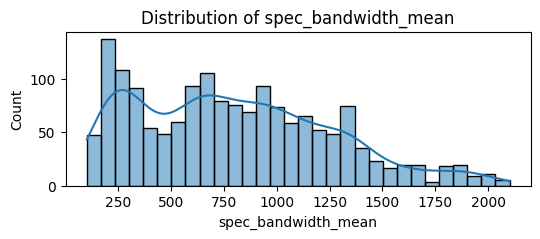

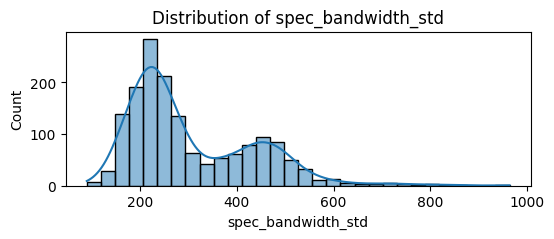

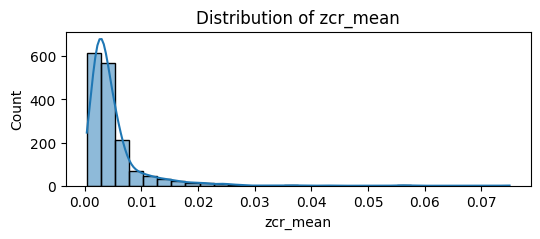

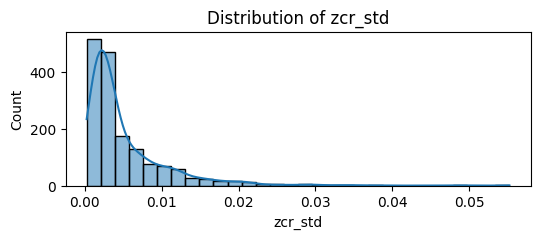

In [3]:
#Feature distributions
df = pd.DataFrame(X, columns=feature_names)
df["label"] = y_labels

for col in feature_names:
    plt.figure(figsize=(6,2))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


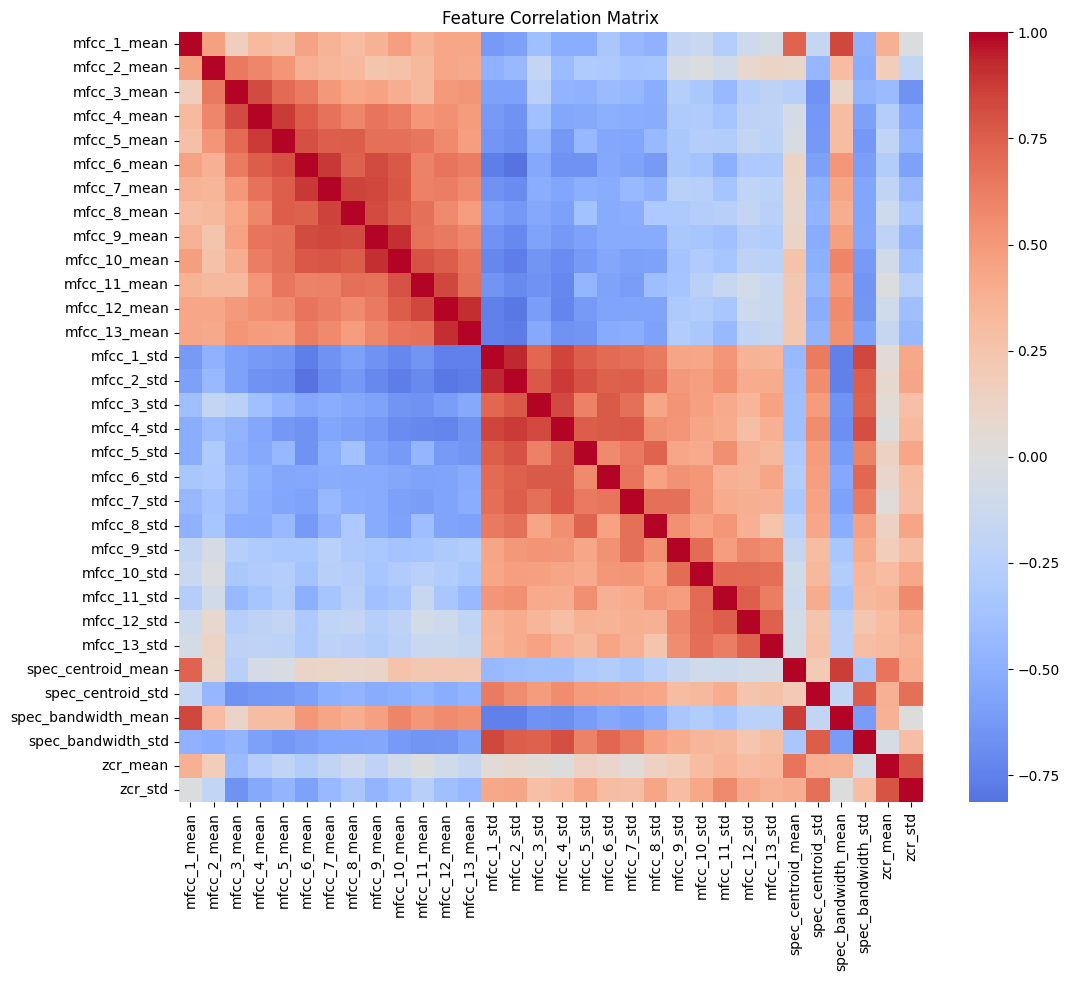

Highly correlated feature pairs:
[('mfcc_9_mean', 'mfcc_10_mean'), ('mfcc_12_mean', 'mfcc_13_mean'), ('mfcc_1_std', 'mfcc_2_std')]


In [4]:
#Feature-feature correlation
corr_matrix = df[feature_names].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

threshold = 0.9
high_corr = [
    (feature_names[i], feature_names[j])
    for i in range(len(feature_names))
    for j in range(i+1, len(feature_names))
    if abs(corr_matrix.iloc[i, j]) > threshold
]

print("Highly correlated feature pairs:")
print(high_corr)


In [5]:
#ANOVA: analysis of variance
f_values, p_values = f_classif(X, y_labels)
anova_results = pd.DataFrame({'feature': feature_names, 'F_value': f_values, 'p_value': p_values})
anova_results = anova_results.sort_values(by='F_value', ascending=False)
print("Top features by ANOVA F-value:")
print(anova_results.head(10))

Top features by ANOVA F-value:
              feature     F_value       p_value
11       mfcc_12_mean  103.330382  1.444930e-23
10       mfcc_11_mean   81.837854  4.158643e-19
12       mfcc_13_mean   78.783692  1.812110e-18
2         mfcc_3_mean   46.152080  1.537320e-11
9        mfcc_10_mean   26.461095  3.019972e-07
3         mfcc_4_mean   23.623985  1.285835e-06
31            zcr_std   19.329573  1.172228e-05
14         mfcc_2_std   18.076251  2.244740e-05
27  spec_centroid_std   17.057324  3.813704e-05
4         mfcc_5_mean   16.192631  5.988221e-05


In [6]:
# Chi-square test 
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_binned = discretizer.fit_transform(X)

chi2_values, p_values_chi2 = chi2(X_binned, y_labels)
chi2_results = pd.DataFrame({'feature': feature_names, 'chi2': chi2_values, 'p_value': p_values_chi2})
chi2_results = chi2_results.sort_values(by='chi2', ascending=False)
print("Top features by Chi-square test:")
print(chi2_results.head(10))

Top features by Chi-square test:
               feature       chi2       p_value
11        mfcc_12_mean  64.768962  8.421526e-16
14          mfcc_2_std  61.650780  4.101047e-15
10        mfcc_11_mean  61.639369  4.124882e-15
12        mfcc_13_mean  37.147619  1.095164e-09
13          mfcc_1_std  34.867081  3.529990e-09
31             zcr_std  27.709610  1.409607e-07
9         mfcc_10_mean  23.476209  1.264681e-06
16          mfcc_4_std  21.453425  3.625279e-06
2          mfcc_3_mean  20.080524  7.424893e-06
26  spec_centroid_mean  19.745040  8.849105e-06


In [7]:
from sklearn.metrics import accuracy_score
import numpy as np

def backward_elimination(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names
):
    remaining_features = feature_names.copy()
    remaining_indices = list(range(X_train.shape[1]))

    model.fit(X_train, y_train)
    best_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Initial accuracy: {best_acc:.4f}")

    improved = True
    while improved:
        improved = False
        best_candidate_acc = best_acc
        feature_to_remove = None

        for i in remaining_indices:
            X_train_tmp = np.delete(X_train, i, axis=1)
            X_test_tmp = np.delete(X_test, i, axis=1)

            model.fit(X_train_tmp, y_train)
            acc = accuracy_score(y_test, model.predict(X_test_tmp))

            if acc >= best_candidate_acc:
                best_candidate_acc = acc
                feature_to_remove = i

        if feature_to_remove is not None:
            removed_feature = remaining_features[remaining_indices.index(feature_to_remove)]
            print(f"Removing {removed_feature} → acc = {best_candidate_acc:.4f}")

            best_acc = best_candidate_acc
            remaining_indices.remove(feature_to_remove)
            remaining_features.remove(removed_feature)
            improved = True

    return remaining_features, best_acc

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
selected_features, acc = backward_elimination(
    lr, X_train_s, X_test_s, y_train, y_test, feature_names
)

Initial accuracy: 0.9751
Removing mfcc_10_std → acc = 0.9782
Removing mfcc_10_mean → acc = 0.9782
Removing mfcc_7_mean → acc = 0.9782


In [9]:
with open("data/features/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)
